In [1]:
import matplotlib.pyplot as plt
import torch
from specter.progress import track

from specter.arrays import radial_profile_2d
from specter.fft import fft2
from specter.imagegenerator import MicrographGenerator
from specter.pdb import PDB
from specter.plots import plot3d
from specter.potential import PotentialBuilder
from specter.filters import butter

%load_ext autoreload
%autoreload 2

In [2]:
# fetch pdb file
pdb_code = "6bdf"
assembly = True  # True: fetches assembly. False: fetches subunit. int: fetches specific assembly #int
pdb = PDB(pdb_code, assembly=True, savefolder="../pdb-data/")

Assemblies available: 1
6bdf: Fetching default Biological Assembly 1
File already exists: ../pdb-data/6bdf-assembly1.cif, skip fetching.


Extracting atom coordinates and element: 0it [00:00, ?it/s]

In [3]:
# Samples 3D scattering potential onto specified grid
n = 256  # number of pixels per axis
dx = 0.83  # angstrom, pixel size.
device = "cpu"
pb = PotentialBuilder(n, dx, pdb.atomic_numbers).to(device)

In [4]:
with torch.no_grad():
    V = pb(pdb.coordinates).clone()

Building element ...:   0%|          | 0/4 [00:00<?, ?it/s]

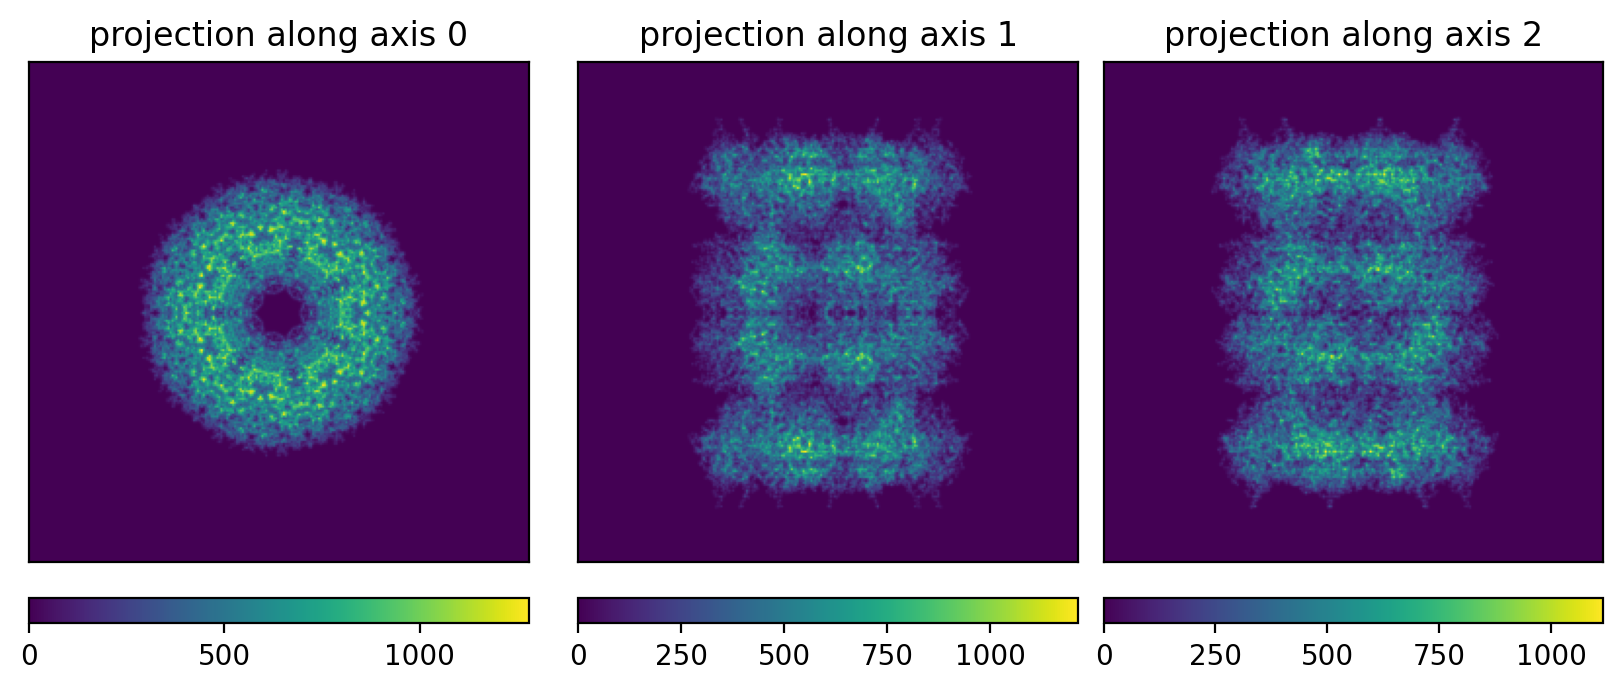

In [5]:
plot3d(V)

## Micrograph class

In [6]:
n_micrographs = 1
energy = 300  # keV
dose_per_angstrom = 20  # e-/A^2
Cs = 2e7  # angstrom. Sherical aberration, typical values are 1-3 mm.
alpha = 0.1
micrograph_size = 4096
# num_frames = int(dose_per_angstrom)  # usually ~ 1-2 e-/A^2/frame
num_frames = 50  # usually ~ 1-2 e-/A^2/frame

In [7]:
# random defocus
defocus_min = 5000  # angstrom
defocus_max = 15000  # angstrom
defocus_A = torch.rand(n_micrographs) * (defocus_max - defocus_min) + defocus_min


# Can include 'cs', 'dfu', 'dfv', 'dfang', 'tiltx', 'tilty', 'phaseshift', 'trefoil1, 'trefoil2'
ctf_params = {
    "cs": torch.tensor([Cs] * n_micrographs),
    "dfu": defocus_A,
}

In [8]:
device = "cuda:1"  # choose cpu if you run out of cuda memory.

In [9]:
V.shape

torch.Size([256, 256, 256])

In [10]:
# Scattering model: 'multislice', 'firstborn', 'projection', 'ctf'
scattering_model = "multislice"

# Aberration model: 'holography' or 'ctf'
aberration_model = "holography"

# Noise model: 'poisson' or None
noise_model = "poisson"
# noise_model = None

# Coincidence radius in angstroms.
# Higher values suppress lower spatial frequencies.
# Set to 0 to recover default Poisson behaviour.
coincidence_radius = 1.8

# Ice model:
#   'random' : fast, worst accuracy
#   'ap'     : alternating projection. moderate speed, low accuracy
#   'gd'     : gradient descent. slow, highest accuracy
#   'mcmc'   : monte carlo markov chain. slowest, medium accuracy, under development.
#   None     : disable ice
ice_model = "gd"
# ice_model = None

ice_thickness = 500  # angstroms, set to 0 for minimum ice thickness = particle box size

crowd_min_distance = pdb.max_diameter  # angstroms, set to None for no crowding
# crowd_min_distance = None

crowd_max_distance_z = None  # if None, defaults to ice_thickness which would result in too many particles above each other.

# pad_fft = False  # True to avoid edge artifacts when if crowd_min_distance is not None
pad_fft = False

chunk_size = 8  # set to None for no chunking (cuda memory might exceed)

model = MicrographGenerator(
    V,
    micrograph_size,
    dx,
    ctf_params,
    energy,
    dose_per_angstrom,
    ice_model=ice_model,
    ice_thickness=ice_thickness,
    scattering_model=scattering_model,
    aberration_model=aberration_model,
    noise_model=noise_model,
    klim=None,
    alpha=alpha,
    crowd_min_distance=crowd_min_distance,
    crowd_max_distance_z=crowd_max_distance_z,
    pad_fft=pad_fft,
    chunk_size=chunk_size,
    move_to_cpu=True,
    coincidence_radius=coincidence_radius,
    num_frames=num_frames,
).to(device)

Rotating duplicates and insert into micrograph:   0%|          | 0/28 [00:00<?, ?it/s]

In [11]:
idx = torch.arange(n_micrographs)
images = []
batchsize = 1  # set higher or lower for faster/slower generation.
with torch.no_grad():
    for i in track(
        range(0, n_micrographs, batchsize), description="Generating micrographs"
    ):
        image = model(idx[i : i + batchsize])
        images.append(image.detach().cpu())

images = torch.concat(images, dim=0)
images.shape

Generating micrographs:   0%|          | 0/1 [00:00<?, ?it/s]

Multislice (Iterative):   0%|          | 0/602 [00:00<?, ?it/s]

Applying coincidence loss:   0%|          | 0/50 [00:00<?, ?it/s]

torch.Size([1, 4096, 4096])

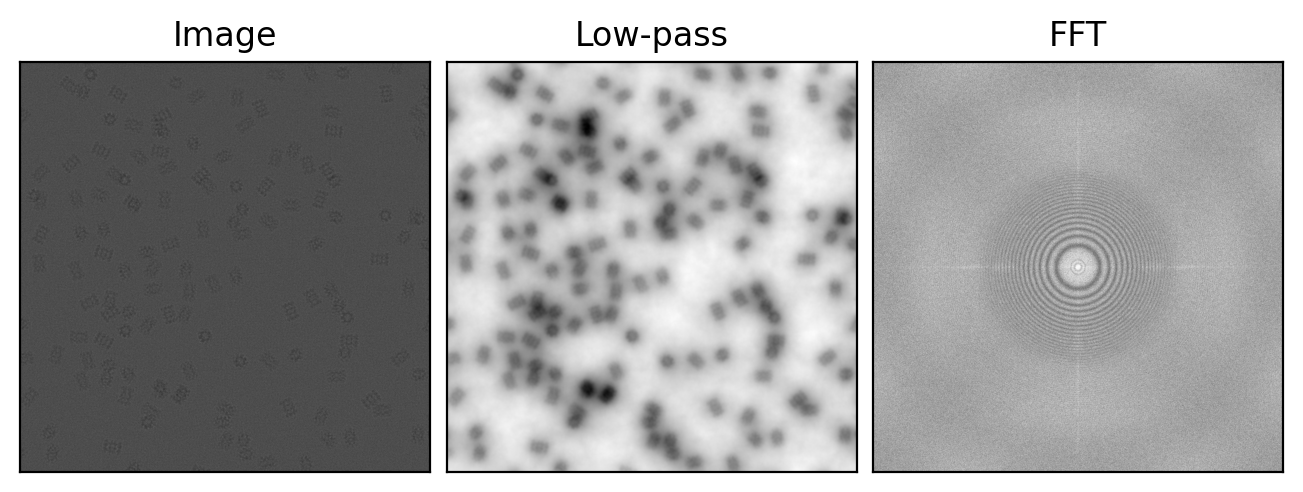

In [12]:
fig, axes = plt.subplots(1, 3, dpi=200, constrained_layout=True)
[ax.set(xticks=[], yticks=[]) for ax in axes.ravel()]
ax = axes[0]
ax.imshow(images[0], cmap="grey")
ax.set_title("Image")

ax = axes[1]
ax.imshow(torch.abs(butter(images[0])), cmap="grey")
# ax.imshow(torch.abs(butter(torch.poisson(torch.ones_like(images[0])))), cmap="grey")
ax.set_title("Low-pass")

ax = axes[2]
ax.imshow(
    torch.abs(fft2(images[0] - images[0].mean(), shift=True)), cmap="grey", vmax=20000
)
ax.set_title("FFT")
plt.show()

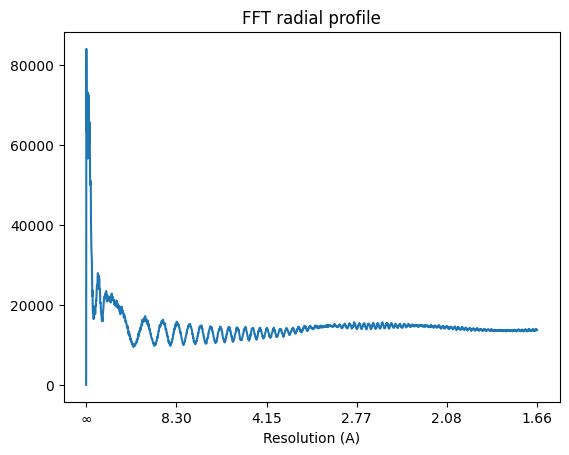

In [13]:
freqs = torch.fft.fftfreq(micrograph_size, dx)
freqs = freqs[: micrograph_size // 2]
rp = radial_profile_2d(torch.abs(fft2(images[0] - images[0].mean(), shift=True)))
plt.plot(freqs, rp[: micrograph_size // 2])
tick_freqs = torch.linspace(freqs[0], freqs[-1], 6)  # Start at index 1 to avoid 1/0
tick_labels = [f"{1 / f:.2f}" for f in tick_freqs]
tick_labels[0] = r"$\infty$"
plt.xticks(tick_freqs, tick_labels)
plt.xlabel("Resolution (A)")
plt.title("FFT radial profile")
plt.show()

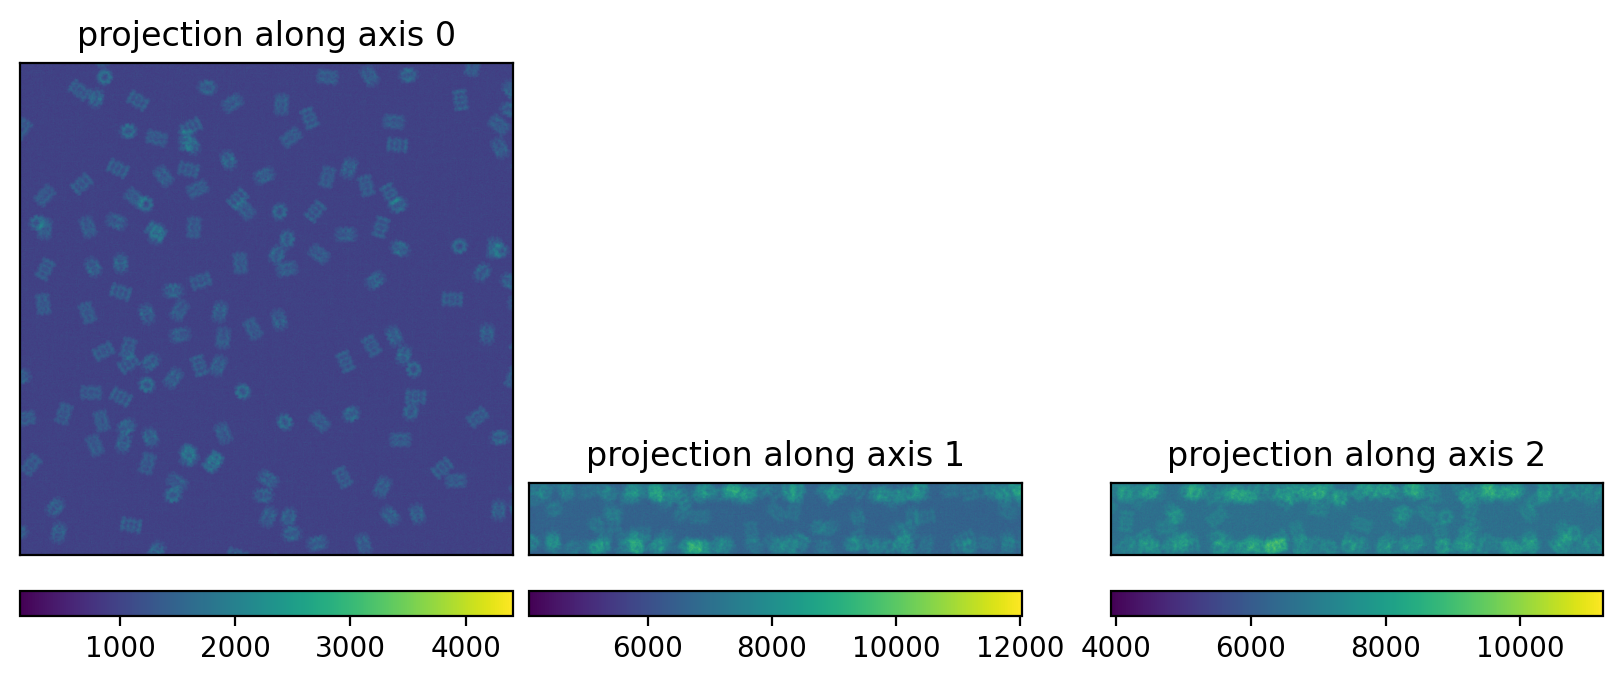

In [14]:
plot3d(model.vol[0].detach().cpu())

In [15]:
# import mrcfile

In [16]:
# for i, im in enumerate(images):
#     with mrcfile.new(f'/scratch/loh/joel/czii/micrograph{i}.mrcs', overwrite=True) as mrc:
#         mrc.set_data(im.numpy())

In [17]:
# def create_particle_starfile(
#     particles,
#     rotations=None,
#     translations=None,
#     alpha=0.1,
#     folderpath='',
#     energy=None,
#     dx=None,
#     starfilename='particles',
#     mrcfilename=None,
#     ctf_params=None
# ):

In [18]:
# fig, axes = plt.subplots(1, 5, dpi=200, constrained_layout=True, figsize=(10, 5))
# for i, ax in enumerate(axes.ravel()):
#     im = ax.imshow(images[i], cmap="grey")
#     ax.set(xticks=[], yticks=[])
#     ax.set_title(f"Defocus: {ctf_params[i,2]/10000:.2f} $\mu$m")
#     fig.colorbar(im, ax=ax, location="bottom")
# plt.show()